In [ ]:
import eval_common as _ec
_ec.set_axis("mechanism")
AXIS = _ec.AXIS
print("AXIS =", AXIS, "| categories:", _ec.MECH_ORDER)

AXIS = mechanism | categories: ['Reliability', 'Bias & Fairness', 'Privacy, Confidentiality & Infringement', 'Security & Misuse', 'Autonomous Actions', 'Governance, Oversight & Explainability']


In [ ]:
from pathlib import Path
import warnings
import gc

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.linalg import eigvals
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)


RANDOM_SEED = 42

DATA_PATH = Path(
    "analysis_table_2016_2025.csv"
)

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATE_COL = "date"
TARGET_COL = "mechanism"
MECH_KEEP = _ec.NAMED_MECHS
MECH_ORDER = _ec.MECH_ORDER
DIMENSION = len(MECH_ORDER)
YEAR_DAYS = 365.25

In [ ]:
DYNAMIC_BETA_GRID = [1 / 60, 1 / 90]
DYNAMIC_RIDGE_GRID = [0.1, 1.0]
DYNAMIC_BASELINE_PENALTY_GRID = [0.01, 0.10]
DYNAMIC_RHO_MAX_GRID = [0.90, 0.95]

SMOOTHING_GRID = [0.0, 0.10, 0.20]

N_STARTS_TUNE = 1
N_STARTS_FINAL = 3
N_SIMS_TUNE = 80
N_SIMS_FINAL = 400
INTEGRATION_STEP_DAYS = 2.0

In [ ]:
df = _ec.load_incidents()
df["mech7"] = df["mechanism"]
print(df.shape, df["date"].min(), "->", df["date"].max())
print(df["mech7"].value_counts().reindex(MECH_ORDER))
counts = _ec.build_counts(df)
full_months = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
from sklearn.metrics import mean_absolute_error, mean_squared_error
evaluate = _ec.evaluate
mlog = _ec.mlog
print(counts.shape, counts.index[0], "->", counts.index[-1])

(1577, 13) 2016-01-01 00:00:00 -> 2026-07-30 00:00:00
mech7
Reliability                                218
Bias & Fairness                            168
Privacy, Confidentiality & Infringement    223
Security & Misuse                          664
Autonomous Actions                         222
Governance, Oversight & Explainability      82
Name: count, dtype: int64
(127, 6) 2016-01 -> 2026-07


In [ ]:
def build_counts(data):
    count_table = (
        data.groupby(["month_period", "mech7"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=MECH_ORDER, fill_value=0)
    )

    full_months = pd.period_range(
        count_table.index.min(),
        count_table.index.max(),
        freq="M"
    )

    count_table = count_table.reindex(
        full_months,
        fill_value=0
    )

    count_table.index.name = "month_period"

    return count_table


counts = build_counts(df)

display(counts.tail())


def mlog(actual_counts, predicted_shares):
    y = np.asarray(actual_counts, dtype=float)

    p = np.clip(
        np.asarray(predicted_shares, dtype=float),
        1e-12,
        1.0
    )

    p = p / p.sum()

    total = y.sum()

    if total <= 0:
        return np.nan

    return float(np.sum(y * np.log(p)) / total)

mech7,Reliability,Bias & Fairness,"Privacy, Confidentiality & Infringement",Security & Misuse,Autonomous Actions,"Governance, Oversight & Explainability"
month_period,,,,,,
2026-03,4,1,2,12,4,2
2026-04,3,1,2,11,7,1
2026-05,6,1,4,11,5,3
2026-06,3,1,5,7,4,0
2026-07,3,0,2,13,7,3


In [ ]:
ORIGIN = df[DATE_COL].min().normalize()


def prepare_marked_events(data, origin=ORIGIN):
    x = (
        data.sort_values([DATE_COL, "incident_id"])
        .copy()
    )

    x["time"] = (
        (x[DATE_COL] - origin).dt.total_seconds()
        / 86400.0
    )

    x["time"] += (
        x.groupby("time").cumcount()
        * 1e-5
    )

    mark_map = {
        category: index
        for index, category in enumerate(MECH_ORDER)
    }

    x["mark_idx"] = x["mech7"].map(mark_map).astype(int)

    return (
        x["time"].to_numpy(dtype=float),
        x["mark_idx"].to_numpy(dtype=int),
    )


full_times, full_marks = prepare_marked_events(df)

T_END = float(
    (df[DATE_COL].max().normalize() - ORIGIN).days + 1
)

print("Observation horizon in days:", T_END)

print("Number of marked events:", len(full_times))

Observation horizon in days: 3864.0
Number of marked events: 1577


In [ ]:
def baseline_design(times, centre):
    t = np.asarray(times, dtype=float)

    annual_angle = 2.0 * np.pi * t / YEAR_DAYS

    return np.column_stack([
        np.ones(len(t)),
        (t - centre) / YEAR_DAYS,
        np.sin(annual_angle),
        np.cos(annual_angle),
    ])


def baseline_intensity(times, coefficients, centre):
    design = baseline_design(
        np.atleast_1d(times),
        centre
    )

    log_intensity = design @ coefficients.T

    return np.exp(
        np.clip(
            log_intensity,
            -30,
            20
        )
    )


def dynamic_baseline_integral(
    coefficients,
    horizon,
    centre,
    step_days=INTEGRATION_STEP_DAYS
):
    grid = np.arange(0.0, horizon, step_days)

    if len(grid) == 0 or grid[-1] < horizon:
        grid = np.append(grid, horizon)

    values = baseline_intensity(
        grid,
        coefficients,
        centre
    )

    integrals = np.trapezoid(
        values,
        grid,
        axis=0
    )

    return integrals

In [ ]:
N_BASELINE_TERMS = 4


def unpack_dynamic_parameters(theta, dimension, beta, rho_max):
    baseline_size = dimension * N_BASELINE_TERMS

    baseline_coefficients = (
        theta[:baseline_size].reshape(dimension, N_BASELINE_TERMS)
    )

    raw_branching = np.exp(
        theta[baseline_size:].reshape(dimension, dimension)
    )

    raw_radius = float(
        np.max(
            np.abs(eigvals(raw_branching))
        ).real
    )

    if raw_radius > rho_max:
        branching = (
            raw_branching
            * rho_max
            / (raw_radius + 1e-12)
        )
    else:
        branching = raw_branching

    excitation_matrix = beta * branching

    return (
        baseline_coefficients,
        excitation_matrix,
        branching,
    )

In [ ]:
def dynamic_marked_hawkes_nll(
    theta,
    times,
    marks,
    horizon,
    dimension,
    beta,
    ridge,
    baseline_penalty,
    rho_max
):
    (
        baseline_coefficients,
        excitation_matrix,
        branching,
    ) = unpack_dynamic_parameters(
        theta,
        dimension,
        beta,
        rho_max
    )

    event_baselines = baseline_intensity(
        times,
        baseline_coefficients,
        centre=horizon
    )

    state = np.zeros(dimension, dtype=float)

    previous_time = 0.0
    log_intensity = 0.0

    for event_index, (event_time, event_mark) in enumerate(zip(times, marks)):
        if event_index > 0:
            state *= np.exp(
                -beta * (event_time - previous_time)
            )

        current_intensity = (
            event_baselines[event_index]
            + excitation_matrix @ state
        )

        marked_intensity = current_intensity[event_mark]

        if (
            marked_intensity <= 0
            or not np.isfinite(marked_intensity)
        ):
            return 1e100

        log_intensity += np.log(marked_intensity)

        state[event_mark] += 1.0
        previous_time = event_time

    baseline_compensator = (
        dynamic_baseline_integral(
            baseline_coefficients,
            horizon,
            centre=horizon
        ).sum()
    )

    excitation_tail = (
        1.0
        - np.exp(
            -beta * (horizon - times)
        )
    )

    excitation_compensator = sum(
        (
            excitation_matrix[:, event_mark].sum()
            / beta
        ) * tail_value
        for event_mark, tail_value in zip(
            marks,
            excitation_tail
        )
    )

    log_likelihood = (
        log_intensity
        - baseline_compensator
        - excitation_compensator
    )

    branching_penalty = ridge * np.sum(branching ** 2)

    trend_coefficients = baseline_coefficients[:, 1]
    seasonal_coefficients = baseline_coefficients[:, 2:4]

    dynamic_penalty = (
        baseline_penalty
        * (
            np.sum(trend_coefficients ** 2)
            + np.sum(seasonal_coefficients ** 2)
        )
    )

    objective = (
        -log_likelihood
        + branching_penalty
        + dynamic_penalty
    )

    if not np.isfinite(objective):
        return 1e100

    return float(objective)

In [ ]:
# %%
def recent_mark_rates(
    times,
    marks,
    horizon,
    dimension,
    window_days=365.25
):
    window_start = max(
        0.0,
        horizon - window_days
    )

    recent_mask = (
        times >= window_start
    )

    recent_duration = max(
        horizon - window_start,
        1.0
    )

    recent_counts = np.bincount(
        marks[recent_mask],
        minlength=dimension
    ).astype(float)

    rates = (
        recent_counts
        / recent_duration
    )

    full_rates = (
        np.bincount(
            marks,
            minlength=dimension
        )
        / max(horizon, 1.0)
    )

    rates = np.where(
        rates > 0,
        rates,
        full_rates
    )

    return np.maximum(
        rates,
        1e-6
    )


def fit_dynamic_marked_hawkes(
    times,
    marks,
    horizon,
    beta,
    ridge,
    baseline_penalty,
    rho_max,
    n_starts
):
    dimension = len(MECH_ORDER)

    starting_rates = recent_mark_rates(
        times,
        marks,
        horizon,
        dimension
    )

    seed = int(
        RANDOM_SEED
        + round(beta * 100000)
        + round(ridge * 1000)
        + round(
            baseline_penalty * 10000
        )
        + round(rho_max * 100)
    )

    local_rng = (
        np.random.default_rng(seed)
    )

    best_result = None

    baseline_bounds = []

    for _ in range(dimension):
        baseline_bounds.extend(
            [
                (-20.0, 3.0),
                (-1.5, 1.5),
                (-2.0, 2.0),
                (-2.0, 2.0),
            ]
        )

    branching_bounds = (
        [(-12.0, 0.0)]
        * (dimension * dimension)
    )

    all_bounds = (
        baseline_bounds
        + branching_bounds
    )

    for start_index in range(n_starts):
        baseline_start = np.zeros(
            (
                dimension,
                N_BASELINE_TERMS
            )
        )

        baseline_start[:, 0] = (
            np.log(
                starting_rates
                * local_rng.uniform(
                    0.5,
                    1.0,
                    dimension
                )
            )
        )

        baseline_start[:, 1] = (
            local_rng.normal(
                0.0,
                0.03,
                dimension
            )
        )

        baseline_start[:, 2] = (
            local_rng.normal(
                0.0,
                0.02,
                dimension
            )
        )

        baseline_start[:, 3] = (
            local_rng.normal(
                0.0,
                0.02,
                dimension
            )
        )

        branching_start = np.full(
            (
                dimension,
                dimension
            ),
            0.01
        )

        np.fill_diagonal(
            branching_start,
            local_rng.uniform(
                0.05,
                0.15,
                dimension
            )
        )

        theta_start = np.r_[
            baseline_start.ravel(),
            np.log(
                branching_start.ravel()
            ),
        ]

        result = minimize(
            dynamic_marked_hawkes_nll,
            theta_start,
            args=(
                times,
                marks,
                horizon,
                dimension,
                beta,
                ridge,
                baseline_penalty,
                rho_max,
            ),
            method="L-BFGS-B",
            bounds=all_bounds,
            options={
                "maxiter": 1200,
                "maxfun": 100000,
                "ftol": 1e-8,
                "gtol": 1e-5,
            },
        )

        if (
            best_result is None
            or result.fun
            < best_result.fun
        ):
            best_result = result

    if best_result is None:
        raise RuntimeError(
            "No dynamic Hawkes optimisation "
            "result was returned."
        )

    (
        baseline_coefficients,
        excitation_matrix,
        branching,
    ) = unpack_dynamic_parameters(
        best_result.x,
        dimension,
        beta,
        rho_max
    )

    spectral_radius = float(
        np.max(
            np.abs(
                eigvals(branching)
            )
        ).real
    )

    return {
        "result": best_result,
        "success": bool(
            best_result.success
        ),
        "message": str(
            best_result.message
        ),
        "baseline_coefficients":
            baseline_coefficients,
        "A": excitation_matrix,
        "K": branching,
        "beta": float(beta),
        "ridge": float(ridge),
        "baseline_penalty":
            float(baseline_penalty),
        "rho_max": float(rho_max),
        "spectral_radius":
            spectral_radius,
        "objective": float(
            best_result.fun
        ),
        "training_horizon":
            float(horizon),
    }

In [ ]:
# %%
test_year = 2025

test_train_df = df[df[DATE_COL].dt.year < test_year].copy()

test_times, test_marks = prepare_marked_events(test_train_df)

test_horizon = float(
    (
        pd.Timestamp(f"{test_year}-01-01")
        - ORIGIN
    ).days
)

test_fit = fit_dynamic_marked_hawkes(
    times=test_times,
    marks=test_marks,
    horizon=test_horizon,
    beta=1 / 60,
    ridge=1.0,
    baseline_penalty=0.10,
    rho_max=0.95,
    n_starts=1,
)

print("Success:", test_fit["success"])
print("Message:", test_fit["message"])
print("Spectral radius:", test_fit["spectral_radius"])
print("Objective:", test_fit["objective"])

Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Spectral radius: 0.4457167991698203
Objective: 3348.632741340999


In [ ]:
def dynamic_baseline_upper_bound(
    coefficients,
    start,
    end,
    centre
):
    intercept = coefficients[:, 0]
    trend = coefficients[:, 1]
    sine = coefficients[:, 2]
    cosine = coefficients[:, 3]

    start_scaled = (start - centre) / YEAR_DAYS
    end_scaled = (end - centre) / YEAR_DAYS

    trend_at_start = trend * start_scaled
    trend_at_end = trend * end_scaled

    maximum_trend = np.maximum(
        trend_at_start,
        trend_at_end
    )

    seasonal_amplitude = np.sqrt(
        sine ** 2 + cosine ** 2
    )

    maximum_log_baseline = (
        intercept
        + maximum_trend
        + seasonal_amplitude
    )

    return np.exp(
        np.clip(
            maximum_log_baseline,
            -30,
            20
        )
    )


def simulate_dynamic_marked_interval(
    fit,
    history_times,
    history_marks,
    start,
    end,
    rng
):
    coefficients = fit["baseline_coefficients"]
    excitation_matrix = fit["A"]
    beta = fit["beta"]
    centre = fit["training_horizon"]

    dimension = len(MECH_ORDER)

    state = np.zeros(
        dimension,
        dtype=float
    )

    for event_time, event_mark in zip(
        history_times,
        history_marks
    ):
        if event_time < start:
            state[event_mark] += np.exp(
                -beta * (start - event_time)
            )

    current_time = start

    simulated_times = []
    simulated_marks = []

    while current_time < end:
        baseline_upper = dynamic_baseline_upper_bound(
            coefficients,
            current_time,
            end,
            centre
        )

        excitation_upper = excitation_matrix @ state

        total_upper = float(
            (baseline_upper + excitation_upper).sum()
        )

        if (
            total_upper <= 0
            or not np.isfinite(total_upper)
        ):
            break

        candidate_time = (
            current_time
            + rng.exponential(1.0 / total_upper)
        )

        if candidate_time >= end:
            break

        state *= np.exp(
            -beta * (candidate_time - current_time)
        )

        candidate_baseline = baseline_intensity(
            [candidate_time],
            coefficients,
            centre
        )[0]

        candidate_intensity = (
            candidate_baseline
            + excitation_matrix @ state
        )

        candidate_total = float(
            candidate_intensity.sum()
        )

        if (
            candidate_total > 0
            and rng.uniform() * total_upper <= candidate_total
        ):
            probabilities = candidate_intensity / candidate_total

            event_mark = int(
                rng.choice(
                    dimension,
                    p=probabilities
                )
            )

            simulated_times.append(candidate_time)
            simulated_marks.append(event_mark)

            state[event_mark] += 1.0

        current_time = candidate_time

    return (
        np.asarray(
            simulated_times,
            dtype=float
        ),
        np.asarray(
            simulated_marks,
            dtype=int
        ),
    )

In [ ]:
def historical_mark_shares(train_marks, pseudocount=0.5):
    mark_counts = (
        np.bincount(
            train_marks,
            minlength=DIMENSION
        ).astype(float)
        + pseudocount
    )

    return mark_counts / mark_counts.sum()


def forecast_dynamic_marked_year(
    fit,
    train_times,
    train_marks,
    fold,
    n_sims,
    smoothing
):
    yr, half = fold
    fstart, fend = _ec.fold_bounds(yr, half)

    start = float(
        (fstart.to_timestamp() - ORIGIN).days
    )

    end = float(
        ((fend + 1).to_timestamp() - ORIGIN).days
    )

    months = pd.period_range(fstart, fend, freq="M")

    month_to_index = {
        str(month): index
        for index, month in enumerate(months)
    }

    accumulated_counts = np.zeros(
        (len(months), DIMENSION),
        dtype=float
    )

    for simulation in range(n_sims):
        simulation_seed = (
            RANDOM_SEED
            + (yr * 100 + half) * 10000
            + simulation
        )

        simulation_rng = np.random.default_rng(simulation_seed)

        (
            simulated_times,
            simulated_marks,
        ) = simulate_dynamic_marked_interval(
            fit,
            train_times,
            train_marks,
            start,
            end,
            simulation_rng
        )

        if len(simulated_times) == 0:
            continue

        simulated_dates = (
            ORIGIN
            + pd.to_timedelta(
                simulated_times,
                unit="D"
            )
        )

        simulated_months = (
            pd.DatetimeIndex(simulated_dates)
            .to_period("M")
        )

        for month, mark in zip(
            simulated_months,
            simulated_marks
        ):
            month_index = month_to_index.get(
                str(month)
            )

            if month_index is not None:
                accumulated_counts[
                    month_index,
                    int(mark)
                ] += 1.0

    mean_counts = accumulated_counts / n_sims

    historical_prior = historical_mark_shares(
        train_marks
    )

    rows = []

    for month_index, month in enumerate(months):
        month_means = mean_counts[month_index]

        if month_means.sum() <= 0:
            month_midpoint = float(
                (
                    month.to_timestamp()
                    + pd.Timedelta(days=14)
                    - ORIGIN
                ).days
            )

            raw_shares = baseline_intensity(
                [month_midpoint],
                fit["baseline_coefficients"],
                fit["training_horizon"]
            )[0]

            raw_shares = raw_shares / raw_shares.sum()

        else:
            raw_shares = month_means / month_means.sum()

        predicted_shares = (
            (1.0 - smoothing) * raw_shares
            + smoothing * historical_prior
        )

        predicted_shares = np.clip(
            predicted_shares,
            1e-12,
            None
        )

        predicted_shares /= predicted_shares.sum()

        for mark, category in enumerate(MECH_ORDER):
            rows.append(
                {
                    "month_period": month,
                    "category": category,
                    "predicted_share": float(
                        predicted_shares[mark]
                    ),
                }
            )

    return pd.DataFrame(rows)

In [ ]:
def attach_actuals(forecast, actual_counts):
    actual_long = (
        actual_counts
        .rename_axis("month_period")
        .reset_index()
        .melt(
            id_vars="month_period",
            var_name="category",
            value_name="actual_count"
        )
    )

    actual_long["actual_total"] = (
        actual_long
        .groupby("month_period")["actual_count"]
        .transform("sum")
    )

    actual_long["actual_share"] = (
        actual_long["actual_count"]
        / actual_long["actual_total"].clip(lower=1e-12)
    )

    output = forecast.copy()

    output["month_period"] = pd.PeriodIndex(
        output["month_period"],
        freq="M"
    )

    return output.merge(
        actual_long[
            [
                "month_period",
                "category",
                "actual_count",
                "actual_share",
            ]
        ],
        on=[
            "month_period",
            "category",
        ],
        how="inner"
    )


def score_dynamic_forecast(scored):
    mae = mean_absolute_error(
        scored["actual_share"],
        scored["predicted_share"]
    )

    rmse = (
        mean_squared_error(
            scored["actual_share"],
            scored["predicted_share"]
        )
        ** 0.5
    )

    log_score = (
        scored
        .groupby("month_period")
        .apply(
            lambda group: mlog(
                group["actual_count"],
                group["predicted_share"]
            ),
            include_groups=False
        )
        .mean()
    )

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "log_score": float(log_score),
    }

In [ ]:
def tune_dynamic_hawkes(outer_train_df, outer_fold):
    val_yr, val_half = _ec.prev_fold(*outer_fold)
    vstart, vend = _ec.fold_bounds(val_yr, val_half)

    inner_train_df = outer_train_df[outer_train_df["month_period"] < vstart].copy()
    validation_counts = counts[(counts.index >= vstart) & (counts.index <= vend)].copy()

    if inner_train_df.empty or validation_counts.empty:
        raise RuntimeError(f"No internal validation fold for {_ec.fold_label(*outer_fold)}.")

    inner_times, inner_marks = prepare_marked_events(inner_train_df)
    inner_horizon = float((vstart.to_timestamp() - ORIGIN).days)

    rows = []
    total_fits = (len(DYNAMIC_BETA_GRID) * len(DYNAMIC_RIDGE_GRID)
                  * len(DYNAMIC_BASELINE_PENALTY_GRID) * len(DYNAMIC_RHO_MAX_GRID))
    fit_number = 0

    for beta in DYNAMIC_BETA_GRID:
        for ridge in DYNAMIC_RIDGE_GRID:
            for baseline_penalty in DYNAMIC_BASELINE_PENALTY_GRID:
                for rho_max in DYNAMIC_RHO_MAX_GRID:
                    fit_number += 1
                    print(f"  Dynamic Hawkes fit {fit_number}/{total_fits}", end="\r")
                    try:
                        fitted = fit_dynamic_marked_hawkes(
                            times=inner_times, marks=inner_marks, horizon=inner_horizon,
                            beta=beta, ridge=ridge, baseline_penalty=baseline_penalty,
                            rho_max=rho_max, n_starts=N_STARTS_TUNE)
                        for smoothing in SMOOTHING_GRID:
                            forecast = forecast_dynamic_marked_year(
                                fit=fitted, train_times=inner_times, train_marks=inner_marks,
                                fold=(val_yr, val_half), n_sims=N_SIMS_TUNE, smoothing=smoothing)
                            scored = attach_actuals(forecast, validation_counts)
                            metrics = score_dynamic_forecast(scored)
                            rows.append({
                                "outer_fold": _ec.fold_label(*outer_fold),
                                "validation_fold": _ec.fold_label(val_yr, val_half),
                                "beta": float(beta), "half_life_days": float(np.log(2) / beta),
                                "ridge": float(ridge),
                                "baseline_penalty": float(baseline_penalty),
                                "rho_max": float(rho_max), "smoothing": float(smoothing),
                                "converged": fitted["success"],
                                "spectral_radius": fitted["spectral_radius"],
                                "validation_mae": metrics["mae"],
                                "validation_rmse": metrics["rmse"],
                                "validation_log_score": metrics["log_score"],
                                "status": "success",
                            })
                    except Exception as error:
                        rows.append({
                            "outer_fold": _ec.fold_label(*outer_fold),
                            "validation_fold": _ec.fold_label(val_yr, val_half),
                            "beta": float(beta), "half_life_days": float(np.log(2) / beta),
                            "ridge": float(ridge),
                            "baseline_penalty": float(baseline_penalty),
                            "rho_max": float(rho_max), "smoothing": np.nan,
                            "converged": False, "spectral_radius": np.nan,
                            "validation_mae": np.nan, "validation_rmse": np.nan,
                            "validation_log_score": np.nan,
                            "status": f"{type(error).__name__}: {error}",
                        })
                    finally:
                        gc.collect()
    print()

    results = pd.DataFrame(rows)
    successful = results[results["status"] == "success"].dropna(
        subset=["validation_log_score", "validation_mae", "validation_rmse"])
    if successful.empty:
        display(results)
        raise RuntimeError(f"All dynamic Hawkes candidates failed for {_ec.fold_label(*outer_fold)}.")

    best = successful.sort_values(
        ["converged", "validation_log_score", "validation_mae",
         "validation_rmse", "spectral_radius", "ridge"],
        ascending=[False, False, True, True, True, False]).iloc[0]

    selected = {"beta": float(best["beta"]), "ridge": float(best["ridge"]),
                "baseline_penalty": float(best["baseline_penalty"]),
                "rho_max": float(best["rho_max"]), "smoothing": float(best["smoothing"])}
    return selected, results

In [ ]:
prediction_frames = []
tuning_frames = []
diagnostic_rows = []
selected_rows = []
fold_models = {}

for (yr, half) in _ec.TEST_FOLDS:
    fold = (yr, half); fold_str = _ec.fold_label(yr, half)
    fstart, fend = _ec.fold_bounds(yr, half)
    print(f"\nTraining before {fold_str}; forecasting {fold_str}")

    outer_train_df = df[df["month_period"] < fstart].copy()
    test_counts = counts[(counts.index >= fstart) & (counts.index <= fend)].copy()
    if outer_train_df.empty or test_counts.empty:
        continue

    try:
        selected, tuning_results = tune_dynamic_hawkes(outer_train_df, fold)
        tuning_frames.append(tuning_results)
        print("Selected:", selected)

        train_times, train_marks = prepare_marked_events(outer_train_df)
        train_horizon = float((fstart.to_timestamp() - ORIGIN).days)

        final_fit = fit_dynamic_marked_hawkes(
            times=train_times, marks=train_marks, horizon=train_horizon,
            beta=selected["beta"], ridge=selected["ridge"],
            baseline_penalty=selected["baseline_penalty"],
            rho_max=selected["rho_max"], n_starts=N_STARTS_FINAL)

        forecast = forecast_dynamic_marked_year(
            fit=final_fit, train_times=train_times, train_marks=train_marks,
            fold=fold, n_sims=N_SIMS_FINAL, smoothing=selected["smoothing"])

    except Exception as error:
        print(f"{fold_str} failed: {type(error).__name__}: {error}")
        continue

    fold_models[fold_str] = final_fit
    selected_rows.append({
        "fold": fold_str, **selected,
        "half_life_days": np.log(2) / selected["beta"],
        "converged": final_fit["success"],
        "spectral_radius": final_fit["spectral_radius"],
    })
    diagnostic_rows.append({
        "fold": fold_str, "success": final_fit["success"], "message": final_fit["message"],
        "beta": final_fit["beta"], "half_life_days": np.log(2) / final_fit["beta"],
        "ridge": final_fit["ridge"], "baseline_penalty": final_fit["baseline_penalty"],
        "rho_max": final_fit["rho_max"], "smoothing": selected["smoothing"],
        "spectral_radius": final_fit["spectral_radius"], "objective": final_fit["objective"],
    })

    scored = attach_actuals(forecast, test_counts)
    scored["model"] = "dynamic_baseline_marked_hawkes"
    scored["fold"] = fold_str
    prediction_frames.append(scored[[
        "model", "fold", "month_period", "category",
        "actual_count", "actual_share", "predicted_share"]])

if not prediction_frames:
    raise RuntimeError("No dynamic Hawkes forecasts were created.")

predictions_dynamic_hawkes = pd.concat(prediction_frames, ignore_index=True)
predictions_dynamic_hawkes["month_period"] = predictions_dynamic_hawkes["month_period"].astype(str)
dynamic_tuning_results = pd.concat(tuning_frames, ignore_index=True)
dynamic_selected_models = pd.DataFrame(selected_rows)
dynamic_diagnostics = pd.DataFrame(diagnostic_rows)


Training before 2020-H1; forecasting 2020-H1
  Dynamic Hawkes fit 16/16
Selected: {'beta': 0.011111111111111112, 'ridge': 0.1, 'baseline_penalty': 0.01, 'rho_max': 0.9, 'smoothing': 0.0}

Training before 2020-H2; forecasting 2020-H2
  Dynamic Hawkes fit 16/16
Selected: {'beta': 0.016666666666666666, 'ridge': 0.1, 'baseline_penalty': 0.1, 'rho_max': 0.95, 'smoothing': 0.1}

Training before 2021-H1; forecasting 2021-H1
  Dynamic Hawkes fit 16/16
Selected: {'beta': 0.011111111111111112, 'ridge': 1.0, 'baseline_penalty': 0.1, 'rho_max': 0.95, 'smoothing': 0.2}

Training before 2021-H2; forecasting 2021-H2
  Dynamic Hawkes fit 16/16
Selected: {'beta': 0.016666666666666666, 'ridge': 1.0, 'baseline_penalty': 0.1, 'rho_max': 0.9, 'smoothing': 0.2}

Training before 2022-H1; forecasting 2022-H1
  Dynamic Hawkes fit 16/16
Selected: {'beta': 0.016666666666666666, 'ridge': 1.0, 'baseline_penalty': 0.01, 'rho_max': 0.9, 'smoothing': 0.2}

Training before 2022-H2; forecasting 2022-H2
  Dynamic Hawke

In [ ]:
share_sums = predictions_dynamic_hawkes.groupby(["fold", "month_period"])["predicted_share"].sum()
print("Predicted monthly share-sum range:", share_sums.min(), "to", share_sums.max())

dynamic_overall, dynamic_by_fold = evaluate(predictions_dynamic_hawkes)

print("Overall dynamic-baseline marked Hawkes performance")
display(dynamic_overall)
print("Performance by fold")
display(dynamic_by_fold)
print("Selected parameters by fold")
display(dynamic_selected_models)
print("Fit diagnostics")
display(dynamic_diagnostics)

Predicted monthly share-sum range: 0.9999999999999998 to 1.0000000000000002
Overall dynamic-baseline marked Hawkes performance


,model,mae,rmse,mean_log_score_per_incident
0,dynamic_baseline_marked_hawkes,0.091684,0.124106,-1.643726


Performance by fold


,model,fold,mae,rmse
0,dynamic_baseline_marked_hawkes,2020-H1,0.151382,0.196932
1,dynamic_baseline_marked_hawkes,2020-H2,0.139304,0.167270
2,dynamic_baseline_marked_hawkes,2021-H1,0.124134,0.144728
3,dynamic_baseline_marked_hawkes,2021-H2,0.110489,0.141966
4,dynamic_baseline_marked_hawkes,2022-H1,0.097479,0.113598
5,dynamic_baseline_marked_hawkes,2022-H2,0.101919,0.130481
6,dynamic_baseline_marked_hawkes,2023-H1,0.089724,0.128113
7,dynamic_baseline_marked_hawkes,2023-H2,0.092766,0.120142
8,dynamic_baseline_marked_hawkes,2024-H1,0.061339,0.081654
9,dynamic_baseline_marked_hawkes,2024-H2,0.054452,0.067335


Selected parameters by fold


,fold,beta,ridge,baseline_penalty,rho_max,smoothing,half_life_days,converged,spectral_radius
0,2020-H1,0.011111,0.1,0.01,0.90,0.0,62.383246,True,0.640133
1,2020-H2,0.016667,0.1,0.10,0.95,0.1,41.588831,True,0.403224
2,2021-H1,0.011111,1.0,0.10,0.95,0.2,62.383246,True,0.399046
3,2021-H2,0.016667,1.0,0.10,0.90,0.2,41.588831,True,0.335863
4,2022-H1,0.016667,1.0,0.01,0.90,0.2,41.588831,True,0.374949
5,2022-H2,0.011111,0.1,0.10,0.95,0.2,62.383246,True,0.331271
6,2023-H1,0.011111,0.1,0.10,0.90,0.2,62.383246,True,0.381489
7,2023-H2,0.016667,1.0,0.10,0.90,0.0,41.588831,True,0.412830
8,2024-H1,0.011111,1.0,0.10,0.90,0.0,62.383246,True,0.391437
9,2024-H2,0.011111,0.1,0.01,0.95,0.0,62.383246,True,0.493521


Fit diagnostics


,fold,success,message,beta,half_life_days,ridge,baseline_penalty,rho_max,smoothing,spectral_radius,objective
0,2020-H1,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.011111,62.383246,0.1,0.01,0.90,0.0,0.640133,842.621013
1,2020-H2,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.016667,41.588831,0.1,0.10,0.95,0.1,0.403224,1032.043946
2,2021-H1,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.011111,62.383246,1.0,0.10,0.95,0.2,0.399046,1225.318180
3,2021-H2,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.016667,41.588831,1.0,0.10,0.90,0.2,0.335863,1407.759334
4,2022-H1,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.016667,41.588831,1.0,0.01,0.90,0.2,0.374949,1572.395104
5,2022-H2,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.011111,62.383246,0.1,0.10,0.95,0.2,0.331271,1777.560354
6,2023-H1,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.011111,62.383246,0.1,0.10,0.90,0.2,0.381489,1994.373363
7,2023-H2,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.016667,41.588831,1.0,0.10,0.90,0.0,0.412830,2312.790453
8,2024-H1,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.011111,62.383246,1.0,0.10,0.90,0.0,0.391437,2565.115913
9,2024-H2,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.011111,62.383246,0.1,0.01,0.95,0.0,0.493521,2955.056021


In [ ]:
print("Selected beta")

display(
    dynamic_selected_models[
        "beta"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("beta")
    .reset_index(
        name="times_selected"
    )
)


print("Selected ridge")

display(
    dynamic_selected_models[
        "ridge"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("ridge")
    .reset_index(
        name="times_selected"
    )
)


print(
    "Selected baseline penalty"
)

display(
    dynamic_selected_models[
        "baseline_penalty"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "baseline_penalty"
    )
    .reset_index(
        name="times_selected"
    )
)


print(
    "Selected spectral-radius cap"
)

display(
    dynamic_selected_models[
        "rho_max"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("rho_max")
    .reset_index(
        name="times_selected"
    )
)


print("Selected smoothing")

display(
    dynamic_selected_models[
        "smoothing"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("smoothing")
    .reset_index(
        name="times_selected"
    )
)

Selected beta


,beta,times_selected
0,0.011111,7
1,0.016667,6


Selected ridge


,ridge,times_selected
0,0.1,6
1,1.0,7


Selected baseline penalty


,baseline_penalty,times_selected
0,0.01,6
1,0.10,7


Selected spectral-radius cap


,rho_max,times_selected
0,0.90,6
1,0.95,7


Selected smoothing


,smoothing,times_selected
0,0.0,6
1,0.1,1
2,0.2,6


In [ ]:
latest_fold = dynamic_selected_models["fold"].iloc[-1]
latest_selection = dynamic_selected_models[
    dynamic_selected_models["fold"] == latest_fold].iloc[0]

final_full_fit = fit_dynamic_marked_hawkes(
    times=full_times, marks=full_marks, horizon=T_END,
    beta=float(latest_selection["beta"]),
    ridge=float(latest_selection["ridge"]),
    baseline_penalty=float(latest_selection["baseline_penalty"]),
    rho_max=float(latest_selection["rho_max"]),
    n_starts=N_STARTS_FINAL)

final_K = pd.DataFrame(final_full_fit["K"], index=MECH_ORDER, columns=MECH_ORDER)
final_K.index.name = "excited_type"; final_K.columns.name = "trigger_type"

baseline_coefficient_names = ["intercept", "trend_per_year", "annual_sine", "annual_cosine"]
final_baseline_coefficients = pd.DataFrame(
    final_full_fit["baseline_coefficients"], index=MECH_ORDER,
    columns=baseline_coefficient_names)

display(pd.DataFrame([{
    "success": final_full_fit["success"], "message": final_full_fit["message"],
    "beta": final_full_fit["beta"], "half_life_days": np.log(2) / final_full_fit["beta"],
    "ridge": final_full_fit["ridge"], "baseline_penalty": final_full_fit["baseline_penalty"],
    "rho_max": final_full_fit["rho_max"], "spectral_radius": final_full_fit["spectral_radius"],
    "objective": final_full_fit["objective"],
}]))
print("Dynamic baseline coefficients"); display(final_baseline_coefficients)
print("Branching matrix"); display(final_K.round(3))

,success,message,beta,half_life_days,ridge,baseline_penalty,rho_max,spectral_radius,objective
0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.016667,41.588831,0.1,0.01,0.95,0.895747,4808.261642


Dynamic baseline coefficients


,intercept,trend_per_year,annual_sine,annual_cosine
Reliability,-3.668379,0.118783,0.391975,0.422846
Bias & Fairness,-3.592817,-0.014578,-0.148297,-0.253144
"Privacy, Confidentiality & Infringement",-3.201877,0.061478,0.038887,0.183578
Security & Misuse,-3.608093,0.375038,1.026441,2.000000
Autonomous Actions,-2.294072,0.154192,0.139599,0.101605
"Governance, Oversight & Explainability",-3.054601,0.229085,0.209674,0.006778


Branching matrix


trigger_type,Reliability,Bias & Fairness,"Privacy, Confidentiality & Infringement",Security & Misuse,Autonomous Actions,"Governance, Oversight & Explainability"
excited_type,,,,,,
Reliability,0.119,0.012,0.001,0.193,0.022,0.010
Bias & Fairness,0.001,0.094,0.001,0.053,0.001,0.012
"Privacy, Confidentiality & Infringement",0.485,0.001,0.000,0.000,0.016,0.006
Security & Misuse,0.019,0.087,0.051,0.878,0.001,0.007
Autonomous Actions,0.094,0.005,0.006,0.000,0.025,0.009
"Governance, Oversight & Explainability",0.013,0.002,0.007,0.006,0.018,0.001


In [ ]:
baseline_interpretation = (
    final_baseline_coefficients
    .copy()
)

baseline_interpretation[
    "annual_baseline_multiplier"
] = np.exp(
    baseline_interpretation[
        "trend_per_year"
    ]
)

baseline_interpretation[
    "approx_annual_percent_change"
] = (
    (
        baseline_interpretation[
            "annual_baseline_multiplier"
        ]
        - 1.0
    )
    * 100.0
)

baseline_interpretation[
    "seasonal_amplitude"
] = np.sqrt(
    baseline_interpretation[
        "annual_sine"
    ] ** 2
    + baseline_interpretation[
        "annual_cosine"
    ] ** 2
)

display(
    baseline_interpretation
    .sort_values(
        "approx_annual_percent_change",
        ascending=False
    )
)

,intercept,trend_per_year,annual_sine,annual_cosine,annual_baseline_multiplier,approx_annual_percent_change,seasonal_amplitude
Security & Misuse,-3.608093,0.375038,1.026441,2.000000,1.455046,45.504634,2.248017
"Governance, Oversight & Explainability",-3.054601,0.229085,0.209674,0.006778,1.257449,25.744894,0.209783
Autonomous Actions,-2.294072,0.154192,0.139599,0.101605,1.166715,16.671512,0.172660
Reliability,-3.668379,0.118783,0.391975,0.422846,1.126125,12.612502,0.576579
"Privacy, Confidentiality & Infringement",-3.201877,0.061478,0.038887,0.183578,1.063407,6.340686,0.187651
Bias & Fairness,-3.592817,-0.014578,-0.148297,-0.253144,0.985528,-1.447248,0.293384


In [ ]:
start_baseline = (
    baseline_intensity(
        [0.0],
        final_full_fit[
            "baseline_coefficients"
        ],
        final_full_fit[
            "training_horizon"
        ]
    )[0]
)

end_baseline = (
    baseline_intensity(
        [T_END],
        final_full_fit[
            "baseline_coefficients"
        ],
        final_full_fit[
            "training_horizon"
        ]
    )[0]
)


baseline_levels = pd.DataFrame(
    {
        "baseline_at_start_per_day":
            start_baseline,
        "baseline_at_end_per_day":
            end_baseline,
    },
    index=MECH_ORDER
)

baseline_levels[
    "end_to_start_ratio"
] = (
    baseline_levels[
        "baseline_at_end_per_day"
    ]
    / baseline_levels[
        "baseline_at_start_per_day"
    ].clip(lower=1e-12)
)

display(
    baseline_levels
    .sort_values(
        "baseline_at_end_per_day",
        ascending=False
    )
)

,baseline_at_start_per_day,baseline_at_end_per_day,end_to_start_ratio
Autonomous Actions,0.021847,0.086300,3.950139
"Governance, Oversight & Explainability",0.004206,0.042405,10.082972
Bias & Fairness,0.024929,0.036898,1.480148
"Privacy, Confidentiality & Infringement",0.025510,0.033986,1.332258
Reliability,0.011085,0.014597,1.316824
Security & Misuse,0.003789,0.002864,0.755859


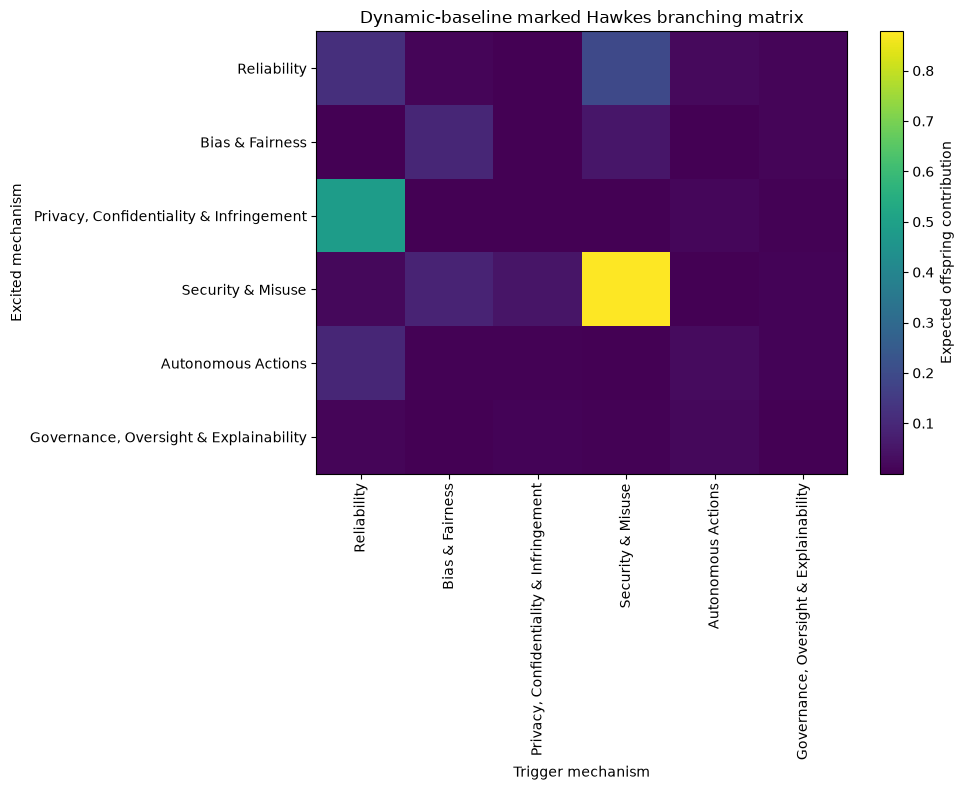

In [ ]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    final_K.to_numpy(),
    aspect="auto"
)

ax.set_xticks(
    range(len(MECH_ORDER)),
    MECH_ORDER,
    rotation=90
)

ax.set_yticks(
    range(len(MECH_ORDER)),
    MECH_ORDER
)

ax.set_xlabel(
    "Trigger mechanism"
)

ax.set_ylabel(
    "Excited mechanism"
)

ax.set_title(
    "Dynamic-baseline marked Hawkes branching matrix"
)

fig.colorbar(
    image,
    ax=ax,
    label=(
        "Expected offspring "
        "contribution"
    )
)

plt.tight_layout()
plt.show()

In [ ]:
import eval_common as _ec
AXIS, OUT = _ec.AXIS, _ec.OUTPUT_DIR
MODEL = "dynamic_baseline_marked_hawkes"

_pred = predictions_dynamic_hawkes.copy()
if "model" not in _pred.columns: _pred.insert(0, "model", MODEL)
_pred["month_period"] = _pred["month_period"].astype(str)
_pred.to_csv(OUT / f"predictions_{MODEL}_{AXIS}.csv", index=False)

_ov = dynamic_overall.copy()
if "model" not in _ov.columns: _ov.insert(0, "model", MODEL)
_ov.to_csv(OUT / f"metrics_{MODEL}_overall_{AXIS}.csv", index=False)
dynamic_by_fold.to_csv(OUT / f"metrics_{MODEL}_byfold_{AXIS}.csv", index=False)

_ss = _pred.groupby(["fold", "month_period"])["predicted_share"].sum()
print("share-sum range:", round(_ss.min(), 6), "to", round(_ss.max(), 6))
assert {"model", "fold", "month_period", "category", "actual_count", "predicted_share"} <= set(_pred.columns)
print("Saved:", f"predictions_{MODEL}_{AXIS}.csv", "+ metrics")

share-sum range: 1.0 to 1.0
Saved: predictions_dynamic_baseline_marked_hawkes_mechanism.csv + metrics
